<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/LSTM/LSTM_IMDB_%E6%83%85%E6%84%9F%E5%88%86%E7%B1%BB%E6%95%99%E7%A8%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM深度学习情感分析教程
## 基于IMDB电影评论数据集的情感分类实战

---

### 📚 教程概述

本教程将带您完整学习如何使用LSTM（长短期记忆网络）对IMDB电影评论进行情感分类。这是一个完整的端到端机器学习项目，适合深度学习初学者。

### 🎯 学习目标

通过本教程，您将学会：
1. **理解LSTM原理**：掌握LSTM在序列数据处理中的优势
2. **文本预处理技术**：学习如何清理和准备文本数据
3. **深度学习建模**：构建和训练LSTM神经网络
4. **模型评估方法**：全面评估模型性能

### 📊 数据集信息

- **数据集名称**: IMDB Dataset of 50K Movie Reviews
- **数据规模**: 50,000条电影评论（25,000训练 + 25,000测试）
- **任务类型**: 二分类情感分析（正面/负面）
- **数据特点**: 真实用户评论，长度不一，包含各种表达方式

### 为什么选择LSTM？

LSTM（Long Short-Term Memory）是一种特殊的RNN（循环神经网络），特别适合处理序列数据：

1. **记忆能力强**：能够记住长期依赖关系
2. **避免梯度消失**：解决传统RNN的梯度消失问题
3. **上下文理解**：能够理解文本的前后文关系
4. **适合变长序列**：处理不同长度的评论文本

### 🛠️ 技术栈

- **Python 3.7+**
- **TensorFlow/Keras**: 深度学习框架
- **Pandas/NumPy**: 数据处理
- **Matplotlib/Seaborn**: 数据可视化
- **Scikit-learn**: 模型评估

---

## 1. 环境设置和库导入

首先导入所需的所有库，并设置基本配置。每个库都有详细的作用说明。

In [1]:
# 设置随机种子，确保结果可重现
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 基础数据处理库
import pandas as pd                    # 数据框操作
import numpy as np                     # 数值计算
import warnings
warnings.filterwarnings('ignore')      # 忽略警告信息

# 数据可视化库
import matplotlib.pyplot as plt        # 基础绘图
import matplotlib.font_manager as fm   # 字体管理
import seaborn as sns                  # 高级绘图

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 机器学习相关库
from sklearn.model_selection import train_test_split  # 数据分割
from sklearn.metrics import (                         # 评估指标
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# 深度学习框架 - TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential         # 序贯模型
from tensorflow.keras.layers import (                  # 神经网络层
    LSTM,
    Dense,
    Embedding,
    Dropout,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer      # 文本分词器
from tensorflow.keras.preprocessing.sequence import pad_sequences  # 序列填充
from tensorflow.keras.callbacks import (
    EarlyStopping,        # 早停
    ModelCheckpoint,      # 模型检查点
    ReduceLROnPlateau     # 学习率调度
)

# 文本处理库
import re                             # 正则表达式
from collections import Counter       # 计数器

# 系统相关
import os
import time
from datetime import datetime

print(f"TensorFlow版本: {tf.__version__}")
print(f"是否有GPU可用: {tf.config.list_physical_devices('GPU')}")
print("✅ 所有库导入成功！")

TensorFlow版本: 2.19.0
是否有GPU可用: []
✅ 所有库导入成功！


## 2. 数据加载和初步探索

让我们加载IMDB数据集并进行初步的数据探索，了解数据的基本特征。

In [3]:
# 数据文件路径
DATA_PATH = '/content/drive/MyDrive/AI_Lecture/ML_DL/LSTM/IMDB Dataset.csv'

# 检查文件是否存在
if not os.path.exists(DATA_PATH):
    print(f"❌ 错误：找不到数据文件 {DATA_PATH}")
    print("请确保数据文件路径正确")
else:
    print(f"✅ 数据文件找到: {DATA_PATH}")

# 加载数据
print("\n📊 正在加载IMDB数据集...")
start_time = time.time()

df = pd.read_csv(DATA_PATH)

load_time = time.time() - start_time
print(f"✅ 数据加载完成！用时: {load_time:.2f}秒")

✅ 数据文件找到: /content/drive/MyDrive/AI_Lecture/ML_DL/LSTM/IMDB Dataset.csv

📊 正在加载IMDB数据集...
✅ 数据加载完成！用时: 2.35秒


In [8]:
# 数据基本信息
print("📋 数据集基本信息:")
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")

📋 数据集基本信息:
数据形状: (50000, 2)
列名: ['review', 'sentiment']


In [9]:
print(f"\n数据类型:")
print(df.dtypes)
print(f"\n内存使用:")
print(df.info(memory_usage='deep'))


数据类型:
review       object
sentiment    object
dtype: object

内存使用:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 67.7 MB
None


In [6]:
# 查看前几条数据
print("👀 数据样例展示:")
print("\n前5条数据:")
display(df.head())

👀 数据样例展示:

前5条数据:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
print("\n随机5条数据:")
display(df.sample(5, random_state=42))


随机5条数据:


,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [10]:
# 缺失值检查
print("🔍 缺失值检查:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() > 0:
    print("\n⚠️ 发现缺失值，需要处理")
else:
    print("\n✅ 没有缺失值")

🔍 缺失值检查:
review       0
sentiment    0
dtype: int64

✅ 没有缺失值


In [11]:
# 重复值检查
duplicate_count = df.duplicated().sum()
print(f"\n🔄 重复值数量: {duplicate_count}")


🔄 重复值数量: 418


📊 情感标签分布分析:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

标签分布比例:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


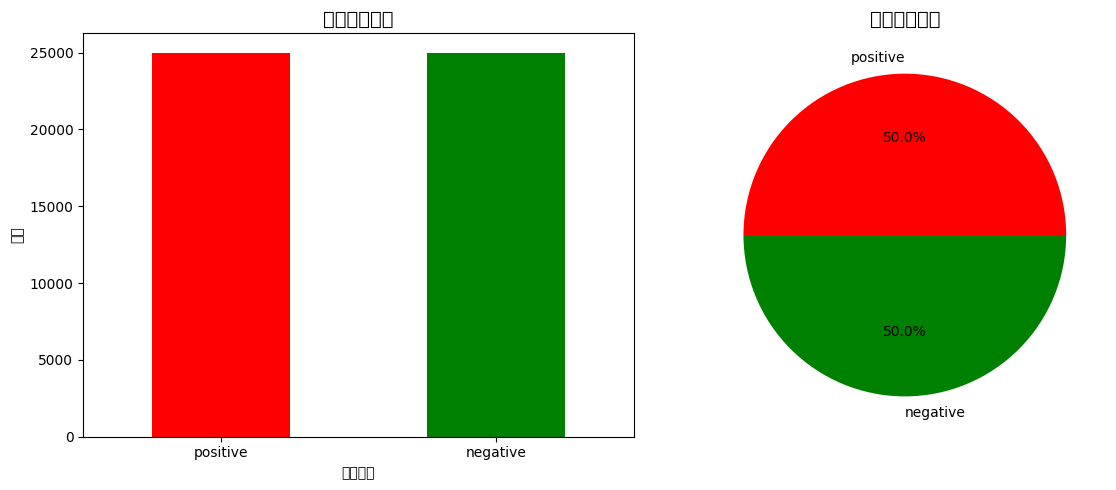


⚖️ 数据平衡性: 1.000
✅ 数据较为平衡


In [12]:
# 情感标签分布
print("📊 情感标签分布分析:")
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)
print(f"\n标签分布比例:")
print(df['sentiment'].value_counts(normalize=True))

# 可视化标签分布
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 柱状图
sentiment_counts.plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('情感标签分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('情感标签')
axes[0].set_ylabel('数量')
axes[0].tick_params(axis='x', rotation=0)

# 饼图
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
           autopct='%1.1f%%', colors=['red', 'green'])
axes[1].set_title('情感标签比例', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 检查数据平衡性
balance_ratio = sentiment_counts.min() / sentiment_counts.max()
print(f"\n⚖️ 数据平衡性: {balance_ratio:.3f}")
if balance_ratio > 0.8:
    print("✅ 数据较为平衡")
else:
    print("⚠️ 数据不平衡，可能需要处理")

📏 文本长度统计分析:

字符长度统计:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: char_length, dtype: float64

单词数量统计:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64

不同情感评论的长度比较:
          char_length                     word_count                   
                 mean median          std       mean median         std
sentiment                                                              
negative   1294.06436  973.0   945.892669  229.46456  174.0  164.947795
positive   1324.79768  968.0  1031.492627  232.84932  172.0  177.497046


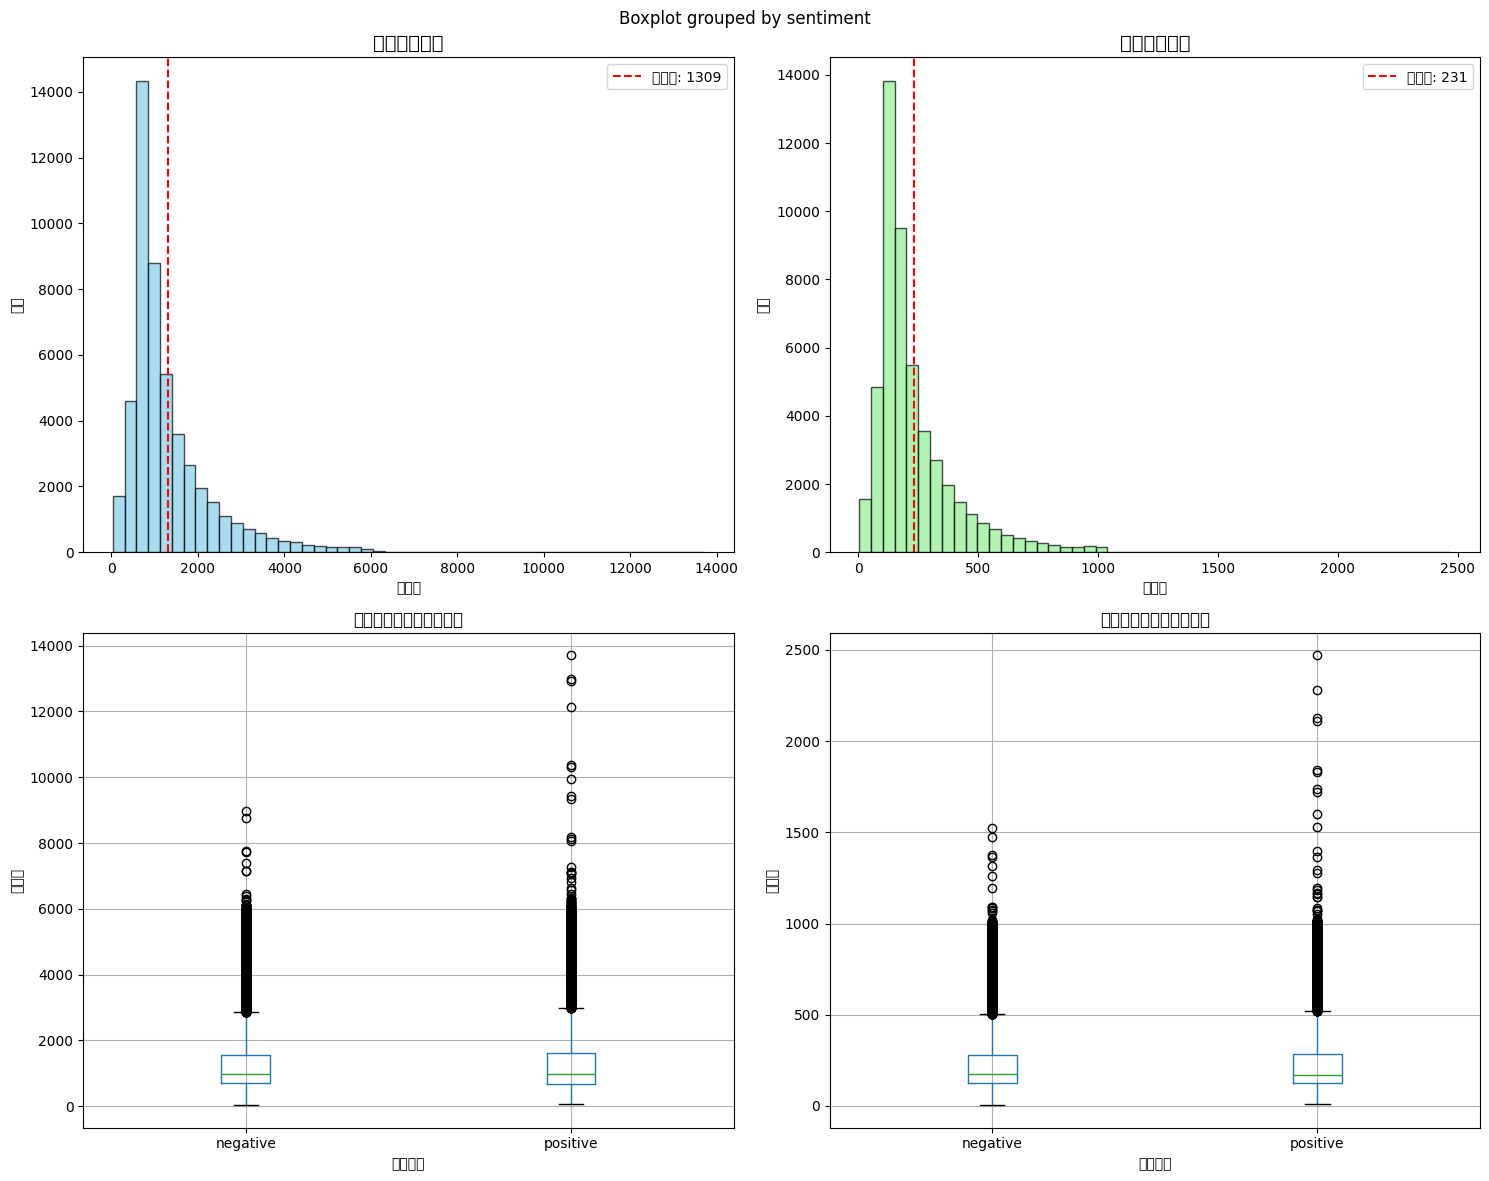


🔍 异常长度评论分析:
最短评论长度: 32 字符
最长评论长度: 13704 字符

📝 最短评论 (32字符):
情感: negative
内容: Read the book, forget the movie!

📝 最长评论 (13704字符):
情感: positive
内容: Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris B...


In [13]:
# 文本长度分析
print("📏 文本长度统计分析:")

# 计算每条评论的字符长度和单词数量
df['char_length'] = df['review'].astype(str).apply(len)
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

# 基本统计信息
print("\n字符长度统计:")
print(df['char_length'].describe())
print("\n单词数量统计:")
print(df['word_count'].describe())

# 不同情感的长度比较
print("\n不同情感评论的长度比较:")
length_by_sentiment = df.groupby('sentiment')[['char_length', 'word_count']].agg(['mean', 'median', 'std'])
print(length_by_sentiment)

# 可视化文本长度分布
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 字符长度分布直方图
axes[0, 0].hist(df['char_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('字符长度分布', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('字符数')
axes[0, 0].set_ylabel('频次')
axes[0, 0].axvline(df['char_length'].mean(), color='red', linestyle='--', label=f'平均值: {df["char_length"].mean():.0f}')
axes[0, 0].legend()

# 单词数量分布直方图
axes[0, 1].hist(df['word_count'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('单词数量分布', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('单词数')
axes[0, 1].set_ylabel('频次')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'平均值: {df["word_count"].mean():.0f}')
axes[0, 1].legend()

# 不同情感的字符长度箱线图
df.boxplot(column='char_length', by='sentiment', ax=axes[1, 0])
axes[1, 0].set_title('不同情感的字符长度分布')
axes[1, 0].set_xlabel('情感标签')
axes[1, 0].set_ylabel('字符数')

# 不同情感的单词数量箱线图
df.boxplot(column='word_count', by='sentiment', ax=axes[1, 1])
axes[1, 1].set_title('不同情感的单词数量分布')
axes[1, 1].set_xlabel('情感标签')
axes[1, 1].set_ylabel('单词数')

plt.tight_layout()
plt.show()

# 找出异常长度的评论
print(f"\n🔍 异常长度评论分析:")
print(f"最短评论长度: {df['char_length'].min()} 字符")
print(f"最长评论长度: {df['char_length'].max()} 字符")

# 显示最短和最长的评论
shortest_review = df.loc[df['char_length'].idxmin()]
longest_review = df.loc[df['char_length'].idxmax()]

print(f"\n📝 最短评论 ({shortest_review['char_length']}字符):")
print(f"情感: {shortest_review['sentiment']}")
print(f"内容: {shortest_review['review']}")

print(f"\n📝 最长评论 ({longest_review['char_length']}字符):")
print(f"情感: {longest_review['sentiment']}")
print(f"内容: {longest_review['review'][:200]}...")  # 只显示前200字符

## 3. 数据预处理

数据预处理是文本分析中最关键的步骤之一。我们需要清理文本，去除噪声，并将文本转换为模型可以理解的数字形式。

### 3.1 文本清理

首先，我们需要清理原始文本数据，去除HTML标签、特殊字符等噪声。

In [16]:
def clean_text(text):
    """
    文本清理函数

    参数:
        text (str): 原始文本

    返回:
        str: 清理后的文本
    """
    # 转换为字符串（防止NaN值）
    text = str(text)

    # 去除HTML标签
    text = re.sub(r'<[^>]+>', '', text)

    # 去除网址链接
    text = re.sub(r'http\S+', '', text)

    # 去除邮箱地址
    text = re.sub(r'\S+@\S+', '', text)

    # 保留字母、数字、空格和基本标点符号
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\;]', '', text)

    # 去除多余的空格
    text = re.sub(r'\s+', ' ', text)

    # 转换为小写
    text = text.lower().strip()

    return text

# 测试文本清理函数
print("🧹 文本清理测试:")
sample_text = df['review'].iloc[0]
print(f"原始文本 (前200字符): {sample_text[:200]}...")
print(f"清理后文本: {clean_text(sample_text)[:200]}...")

# 应用文本清理到整个数据集
print("\n🔄 正在清理所有文本数据...")
start_time = time.time()

df['cleaned_review'] = df['review'].apply(clean_text)

clean_time = time.time() - start_time
print(f"✅ 文本清理完成！用时: {clean_time:.2f}秒")

# 检查清理后的效果
print(f"\n📊 清理效果对比:")
print(f"清理前平均长度: {df['char_length'].mean():.1f} 字符")
print(f"清理后平均长度: {df['cleaned_review'].apply(len).mean():.1f} 字符")

# 显示清理前后的对比示例
print(f"\n🔍 清理前后对比示例:")
for i in range(3):
    print(f"\n示例 {i+1}:")
    print(f"原文: {df['review'].iloc[i][:150]}...")
    print(f"清理后: {df['cleaned_review'].iloc[i][:150]}...")

🧹 文本清理测试:
原始文本 (前200字符): One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...
清理后文本: one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its...

🔄 正在清理所有文本数据...
✅ 文本清理完成！用时: 10.47秒

📊 清理效果对比:
清理前平均长度: 1309.4 字符
清理后平均长度: 1269.4 字符

🔍 清理前后对比示例:

示例 1:
原文: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with...
清理后: one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked. they are right, as this is exactly what happened with ...

示例 2:
原文: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a com

### 3.2 文本分词和编码

接下来，我们需要将清理后的文本转换为数字序列，这样神经网络才能处理它们。

🔢 开始文本分词和编码...
正在构建词汇表...
✅ 词汇表构建完成!
总词汇量: 150129
使用词汇量: 10000
词汇表大小 (包含填充): 150130

📚 最常见的20个词汇:
 1: <OOV>
 2: the
 3: and
 4: a
 5: of
 6: to
 7: is
 8: in
 9: it
10: i
11: this
12: that
13: was
14: as
15: with
16: for
17: movie
18: but
19: film
20: on

🔄 将文本转换为数字序列...
转换完成! 序列数量: 50000

🔍 文本转换示例:
原始文本: one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked. they...
数字序列: [28, 5, 2, 77, 1963, 45, 1063, 12, 101, 145, 40, 421, 3095, 389, 466, 26, 3145, 34, 23, 201]...

📊 序列长度统计:
平均长度: 228.5
中位数长度: 171.0
最短长度: 6
最长长度: 2451
设定最大长度: 100


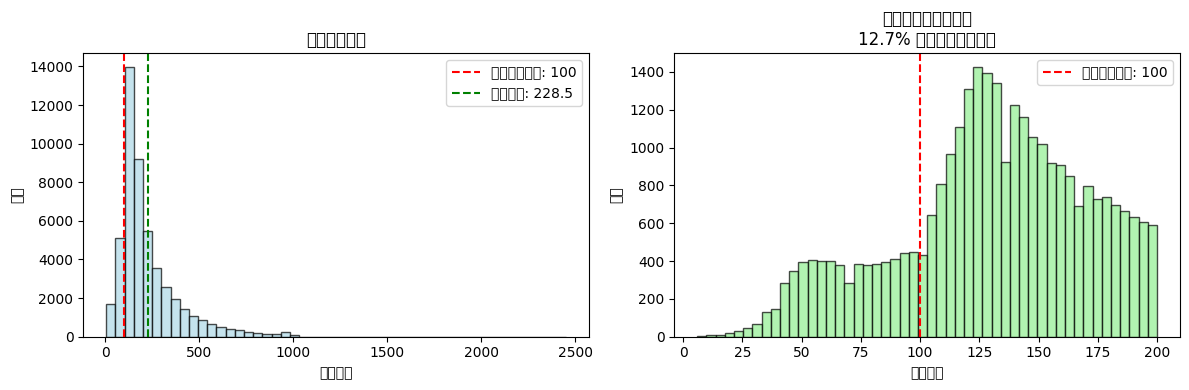


📈 12.7% 的序列长度在设定的最大长度 100 以内


In [17]:
# 设置分词器参数
MAX_WORDS = 10000        # 词汇表最大大小
MAX_LENGTH = 100         # 序列最大长度
OOV_TOKEN = "<OOV>"      # 未知词标记

print("🔢 开始文本分词和编码...")

# 创建分词器
tokenizer = Tokenizer(
    num_words=MAX_WORDS,     # 只保留最常见的10000个词
    oov_token=OOV_TOKEN,     # 设置未知词标记
    lower=True               # 转换为小写
)

# 在训练数据上拟合分词器
print("正在构建词汇表...")
tokenizer.fit_on_texts(df['cleaned_review'])

# 获取词汇表信息
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for padding token

print(f"✅ 词汇表构建完成!")
print(f"总词汇量: {len(word_index)}")
print(f"使用词汇量: {min(MAX_WORDS, len(word_index))}")
print(f"词汇表大小 (包含填充): {vocab_size}")

# 显示最常见的词汇
print(f"\n📚 最常见的20个词汇:")
most_common_words = list(word_index.items())[:20]
for word, index in most_common_words:
    print(f"{index:2d}: {word}")

# 将文本转换为数字序列
print(f"\n🔄 将文本转换为数字序列...")
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

print(f"转换完成! 序列数量: {len(sequences)}")

# 显示转换示例
print(f"\n🔍 文本转换示例:")
sample_idx = 0
print(f"原始文本: {df['cleaned_review'].iloc[sample_idx][:100]}...")
print(f"数字序列: {sequences[sample_idx][:20]}...")  # 只显示前20个数字

# 分析序列长度分布
sequence_lengths = [len(seq) for seq in sequences]
print(f"\n📊 序列长度统计:")
print(f"平均长度: {np.mean(sequence_lengths):.1f}")
print(f"中位数长度: {np.median(sequence_lengths):.1f}")
print(f"最短长度: {min(sequence_lengths)}")
print(f"最长长度: {max(sequence_lengths)}")
print(f"设定最大长度: {MAX_LENGTH}")

# 可视化序列长度分布
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(sequence_lengths, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.axvline(MAX_LENGTH, color='red', linestyle='--', label=f'设定最大长度: {MAX_LENGTH}')
plt.axvline(np.mean(sequence_lengths), color='green', linestyle='--', label=f'平均长度: {np.mean(sequence_lengths):.1f}')
plt.title('序列长度分布')
plt.xlabel('序列长度')
plt.ylabel('频次')
plt.legend()

plt.subplot(1, 2, 2)
# 显示长度在MAX_LENGTH以内的比例
within_max_length = sum(1 for length in sequence_lengths if length <= MAX_LENGTH)
percentage = within_max_length / len(sequence_lengths) * 100
plt.hist([l for l in sequence_lengths if l <= MAX_LENGTH*2], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.axvline(MAX_LENGTH, color='red', linestyle='--', label=f'设定最大长度: {MAX_LENGTH}')
plt.title(f'截断后序列长度分布\n{percentage:.1f}% 数据在最大长度内')
plt.xlabel('序列长度')
plt.ylabel('频次')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n📈 {percentage:.1f}% 的序列长度在设定的最大长度 {MAX_LENGTH} 以内")

### 3.3 序列填充和数据分割

将不同长度的序列填充为相同长度，并准备训练数据。

In [18]:
# 序列填充
print("🔧 序列填充处理...")
X = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,    # 最大长度
    padding='post',       # 在后面填充
    truncating='post'     # 从后面截断
)

print(f"✅ 序列填充完成!")
print(f"填充后数据形状: {X.shape}")
print(f"数据类型: {X.dtype}")

# 标签编码
print(f"\n🏷️ 标签编码...")
label_map = {'negative': 0, 'positive': 1}
y = df['sentiment'].map(label_map).values

print(f"标签编码完成!")
print(f"标签形状: {y.shape}")
print(f"标签分布: {np.bincount(y)}")

# 显示填充示例
print(f"\n🔍 填充示例:")
sample_idx = 0
print(f"原始序列长度: {len(sequences[sample_idx])}")
print(f"原始序列: {sequences[sample_idx][:10]}...")
print(f"填充后序列: {X[sample_idx][:15]}...")
print(f"序列末尾: ...{X[sample_idx][-15:]}")

🔧 序列填充处理...
✅ 序列填充完成!
填充后数据形状: (50000, 100)
数据类型: int32

🏷️ 标签编码...
标签编码完成!
标签形状: (50000,)
标签分布: [25000 25000]

🔍 填充示例:
原始序列长度: 308
原始序列: [28, 5, 2, 77, 1963, 45, 1063, 12, 101, 145]...
填充后序列: [  28    5    2   77 1963   45 1063   12  101  145   40  421 3095  389
  466]...
序列末尾: ...[   2  666    9    7  475 3095   14   12    7    2    1  346    6    2
    1]


📊 数据集分割...
✅ 数据分割完成!
训练集: (30000, 100) - 30000 样本
验证集: (10000, 100) - 10000 样本
测试集: (10000, 100) - 10000 样本

📈 各数据集标签分布:
训练集 - 负面: 15000, 正面: 15000
验证集 - 负面: 5000, 正面: 5000
测试集 - 负面: 5000, 正面: 5000


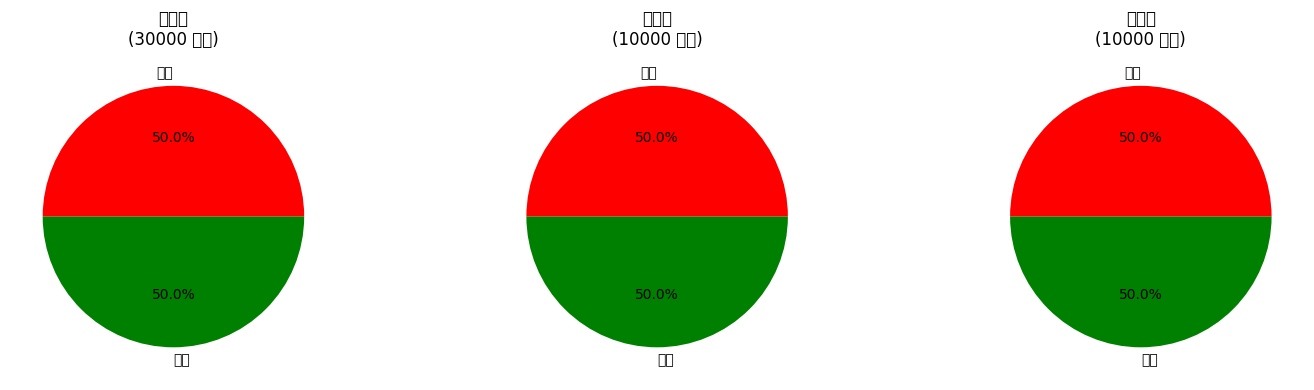

In [19]:
# 数据分割
print("📊 数据集分割...")

# 先分割出训练+验证集和测试集
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% 作为测试集
    random_state=SEED,
    stratify=y            # 保持标签分布
)

# 再将训练+验证集分割为训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,       # 25% of 80% = 20% 作为验证集
    random_state=SEED,
    stratify=y_temp
)

print(f"✅ 数据分割完成!")
print(f"训练集: {X_train.shape} - {len(y_train)} 样本")
print(f"验证集: {X_val.shape} - {len(y_val)} 样本")
print(f"测试集: {X_test.shape} - {len(y_test)} 样本")

# 检查标签分布
print(f"\n📈 各数据集标签分布:")
print(f"训练集 - 负面: {sum(y_train == 0)}, 正面: {sum(y_train == 1)}")
print(f"验证集 - 负面: {sum(y_val == 0)}, 正面: {sum(y_val == 1)}")
print(f"测试集 - 负面: {sum(y_test == 0)}, 正面: {sum(y_test == 1)}")

# 可视化数据分割结果
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [('训练集', y_train), ('验证集', y_val), ('测试集', y_test)]

for i, (name, labels) in enumerate(datasets):
    counts = np.bincount(labels)
    axes[i].pie(counts, labels=['负面', '正面'], autopct='%1.1f%%',
               colors=['red', 'green'])
    axes[i].set_title(f'{name}\n({len(labels)} 样本)')

plt.tight_layout()
plt.show()

## 4. LSTM模型构建

现在我们构建LSTM模型。首先了解LSTM的工作原理，然后实现模型架构。

### 4.1 LSTM原理说明

LSTM（长短期记忆网络）通过三个门控机制来控制信息流：

1. **遗忘门（Forget Gate）**：决定从细胞状态中丢弃什么信息
2. **输入门（Input Gate）**：决定在细胞状态中存储什么新信息
3. **输出门（Output Gate）**：决定细胞状态的哪些部分作为输出

这种设计使LSTM能够：
- 记住重要的长期依赖关系
- 忘记不重要的信息
- 避免梯度消失问题

### 4.2 模型架构实现

In [20]:
# 模型参数设置
EMBEDDING_DIM = 128      # 词嵌入维度
LSTM_UNITS = 64          # LSTM单元数
DENSE_UNITS = 32         # 全连接层单元数
DROPOUT_RATE = 0.3       # Dropout比例

#[64, 32]

print("🏗️ 构建LSTM模型...")

def create_lstm_model(vocab_size, embedding_dim, lstm_units, dense_units, max_length, dropout_rate):
    """
    创建LSTM情感分类模型

    参数:
        vocab_size: 词汇表大小
        embedding_dim: 词嵌入维度
        lstm_units: LSTM单元数
        dense_units: 全连接层单元数
        max_length: 最大序列长度
        dropout_rate: Dropout比例

    返回:
        model: 编译好的Keras模型
    """

    model = Sequential([
        # 词嵌入层：将词汇ID转换为密集向量
        Embedding(
            input_dim=vocab_size,      # 词汇表大小
            output_dim=embedding_dim,   # 嵌入向量维度
            input_length=max_length,    # 输入序列长度
            name='embedding'
        ),

        # Dropout层：防止过拟合
        Dropout(dropout_rate, name='embedding_dropout'),

        # LSTM层：处理序列数据
        LSTM(
            units=lstm_units,           # LSTM单元数
            dropout=dropout_rate,       # LSTM内部dropout
            recurrent_dropout=dropout_rate,  # 循环连接dropout
            return_sequences=False,     # 只返回最后一个时间步的输出
            name='lstm'
        ),

        # 全连接层：进行特征变换
        Dense(
            units=dense_units,
            activation='relu',
            name='dense'
        ),

        # Dropout层
        Dropout(dropout_rate, name='dense_dropout'),

        # 输出层：二分类
        Dense(
            units=1,
            activation='sigmoid',       # sigmoid激活函数输出0-1概率
            name='output'
        )
    ])

    return model

# 创建模型
model = create_lstm_model(
    vocab_size=min(MAX_WORDS, len(word_index)) + 1,
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    dense_units=DENSE_UNITS,
    max_length=MAX_LENGTH,
    dropout_rate=DROPOUT_RATE
)

# 显示模型结构
print("✅ 模型创建完成!")
print("\n📋 模型结构:")
model.summary()

# 可视化模型架构
try:
    from tensorflow.keras.utils import plot_model
    plot_model(model, to_file='lstm_model.png', show_shapes=True, show_layer_names=True)
    print("\n🖼️ 模型架构图已保存为 lstm_model.png")
except Exception as e:
    print(f"\n⚠️ 无法生成模型架构图: {e}")

🏗️ 构建LSTM模型...
✅ 模型创建完成!

📋 模型结构:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout (Dropout)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


⚠️ 无法生成模型架构图: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.


### 4.3 模型编译

In [22]:
# 编译模型
print("⚙️ 编译模型...")

model.compile(
    optimizer='adam',              # Adam优化器：自适应学习率
    loss='binary_crossentropy',   # 二分类交叉熵损失
    metrics=['accuracy']          # 监控准确率
)

print("✅ 模型编译完成!")

# 显示编译参数
print(f"\n🔧 编译参数:")
print(f"优化器: Adam")
print(f"损失函数: binary_crossentropy")
print(f"评估指标: accuracy")

# 计算模型参数数量
# Build the model before calling count_params
model.build(input_shape=(None, MAX_LENGTH))
total_params = model.count_params()
print(f"\n📊 模型参数统计:")
print(f"总参数数量: {total_params:,}")

# 分层参数统计
for layer in model.layers:
    layer_params = layer.count_params()
    print(f"{layer.name}: {layer_params:,} 参数")

⚙️ 编译模型...
✅ 模型编译完成!

🔧 编译参数:
优化器: Adam
损失函数: binary_crossentropy
评估指标: accuracy

📊 模型参数统计:
总参数数量: 1,331,649
embedding: 1,280,128 参数
embedding_dropout: 0 参数
lstm: 49,408 参数
dense: 2,080 参数
dense_dropout: 0 参数
output: 33 参数


## 5. 模型训练

现在开始训练我们的LSTM模型，并设置各种回调函数来优化训练过程。

### 5.1 训练配置

In [23]:
# 训练参数
BATCH_SIZE = 32          # 批次大小
EPOCHS = 10              # 训练轮数
VALIDATION_SPLIT = None  # 使用单独的验证集

print("🎯 设置训练配置...")

# 设置回调函数
callbacks = [
    # 早停：验证损失不再改善时停止训练
    EarlyStopping(
        monitor='val_loss',      # 监控验证损失
        patience=3,              # 容忍3个epoch无改善
        restore_best_weights=True,  # 恢复最佳权重
        verbose=1
    ),

    # 模型检查点：保存最佳模型
    ModelCheckpoint(
        filepath='best_lstm_model.h5',
        monitor='val_accuracy',  # 监控验证准确率
        save_best_only=True,     # 只保存最佳模型
        save_weights_only=False,
        verbose=1
    ),

    # 学习率调度：验证损失不改善时降低学习率
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,              # 学习率减半
        patience=2,              # 2个epoch后开始调整 # warm-up
        min_lr=1e-6,             # 最小学习率
        verbose=1
    )
]

print(f"✅ 训练配置完成!")
print(f"\n🔧 训练参数:")
print(f"批次大小: {BATCH_SIZE}")
print(f"训练轮数: {EPOCHS}")
print(f"早停耐心度: 3")
print(f"学习率调度: 启用")
print(f"模型检查点: 启用")

🎯 设置训练配置...
✅ 训练配置完成!

🔧 训练参数:
批次大小: 32
训练轮数: 10
早停耐心度: 3
学习率调度: 启用
模型检查点: 启用


### 5.2 开始训练

In [24]:
import time

# 开始训练
print("🚀 开始训练LSTM模型...")
print(f"训练数据: {X_train.shape}")
print(f"验证数据: {X_val.shape}")
print("=" * 50)

start_time = time.time()

# 训练模型
history = model.fit(
    X_train, y_train,                    # 训练数据
    batch_size=BATCH_SIZE,               # 批次大小
    epochs=EPOCHS,                       # 训练轮数
    validation_data=(X_val, y_val),      # 验证数据
    callbacks=callbacks,                 # 回调函数
    verbose=1                            # 显示训练过程
)

training_time = time.time() - start_time
print(f"\n✅ 训练完成! 用时: {training_time:.2f}秒 ({training_time/60:.1f}分钟)")

# 训练历史摘要
print(f"\n📊 训练历史摘要:")
print(f"训练轮数: {len(history.history['loss'])}")

# 注意：历史中是否包含 'accuracy'/'val_accuracy' 取决于 model.compile 的配置
if "val_accuracy" in history.history:
    print(f"最佳验证准确率: {max(history.history['val_accuracy']):.4f}")
if "val_loss" in history.history:
    print(f"最佳验证损失: {min(history.history['val_loss']):.4f}")
if "accuracy" in history.history:
    print(f"最终训练准确率: {history.history['accuracy'][-1]:.4f}")
print(f"最终训练损失: {history.history['loss'][-1]:.4f}")

🚀 开始训练LSTM模型...
训练数据: (30000, 100)
验证数据: (10000, 100)
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.6006 - loss: 0.6531
Epoch 1: val_accuracy improved from -inf to 0.79200, saving model to best_lstm_model.h5


938/938 ━━━━━━━━━━━━━━━━━━━━ 171s 176ms/step - accuracy: 0.6007 - loss: 0.6531 - val_accuracy: 0.7920 - val_loss: 0.4802 - learning_rate: 0.0010
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7633 - loss: 0.5166
Epoch 2: val_accuracy improved from 0.79200 to 0.80760, saving model to best_lstm_model.h5


938/938 ━━━━━━━━━━━━━━━━━━━━ 210s 185ms/step - accuracy: 0.7633 - loss: 0.5166 - val_accuracy: 0.8076 - val_loss: 0.4488 - learning_rate: 0.0010
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8242 - loss: 0.4287
Epoch 3: val_accuracy improved from 0.80760 to 0.82580, saving model to best_lstm_model.h5


938/938 ━━━━━━━━━━━━━━━━━━━━ 158s 168ms/step - accuracy: 0.8242 - loss: 0.4287 - val_accuracy: 0.8258 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8642 - loss: 0.3442
Epoch 4: val_accuracy did not improve from 0.82580
938/938 ━━━━━━━━━━━━━━━━━━━━ 196s 162ms/step - accuracy: 0.8642 - loss: 0.3442 - val_accuracy: 0.8237 - val_loss: 0.4101 - learning_rate: 0.0010
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8851 - loss: 0.2932
Epoch 5: val_accuracy improved from 0.82580 to 0.83140, saving model to best_lstm_model.h5



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
938/938 ━━━━━━━━━━━━━━━━━━━━ 198s 158ms/step - accuracy: 0.8851 - loss: 0.2932 - val_accuracy: 0.8314 - val_loss: 0.4166 - learning_rate: 0.0010
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9050 - loss: 0.2490
Epoch 6: val_accuracy improved from 0.83140 to 0.83600, saving model to best_lstm_model.h5


938/938 ━━━━━━━━━━━━━━━━━━━━ 204s 160ms/step - accuracy: 0.9050 - loss: 0.2490 - val_accuracy: 0.8360 - val_loss: 0.4684 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

✅ 训练完成! 用时: 1188.81秒 (19.8分钟)

📊 训练历史摘要:
训练轮数: 6
最佳验证准确率: 0.8360
最佳验证损失: 0.4084
最终训练准确率: 0.9109
最终训练损失: 0.2378


### 5.3 训练过程可视化

📈 可视化训练过程...


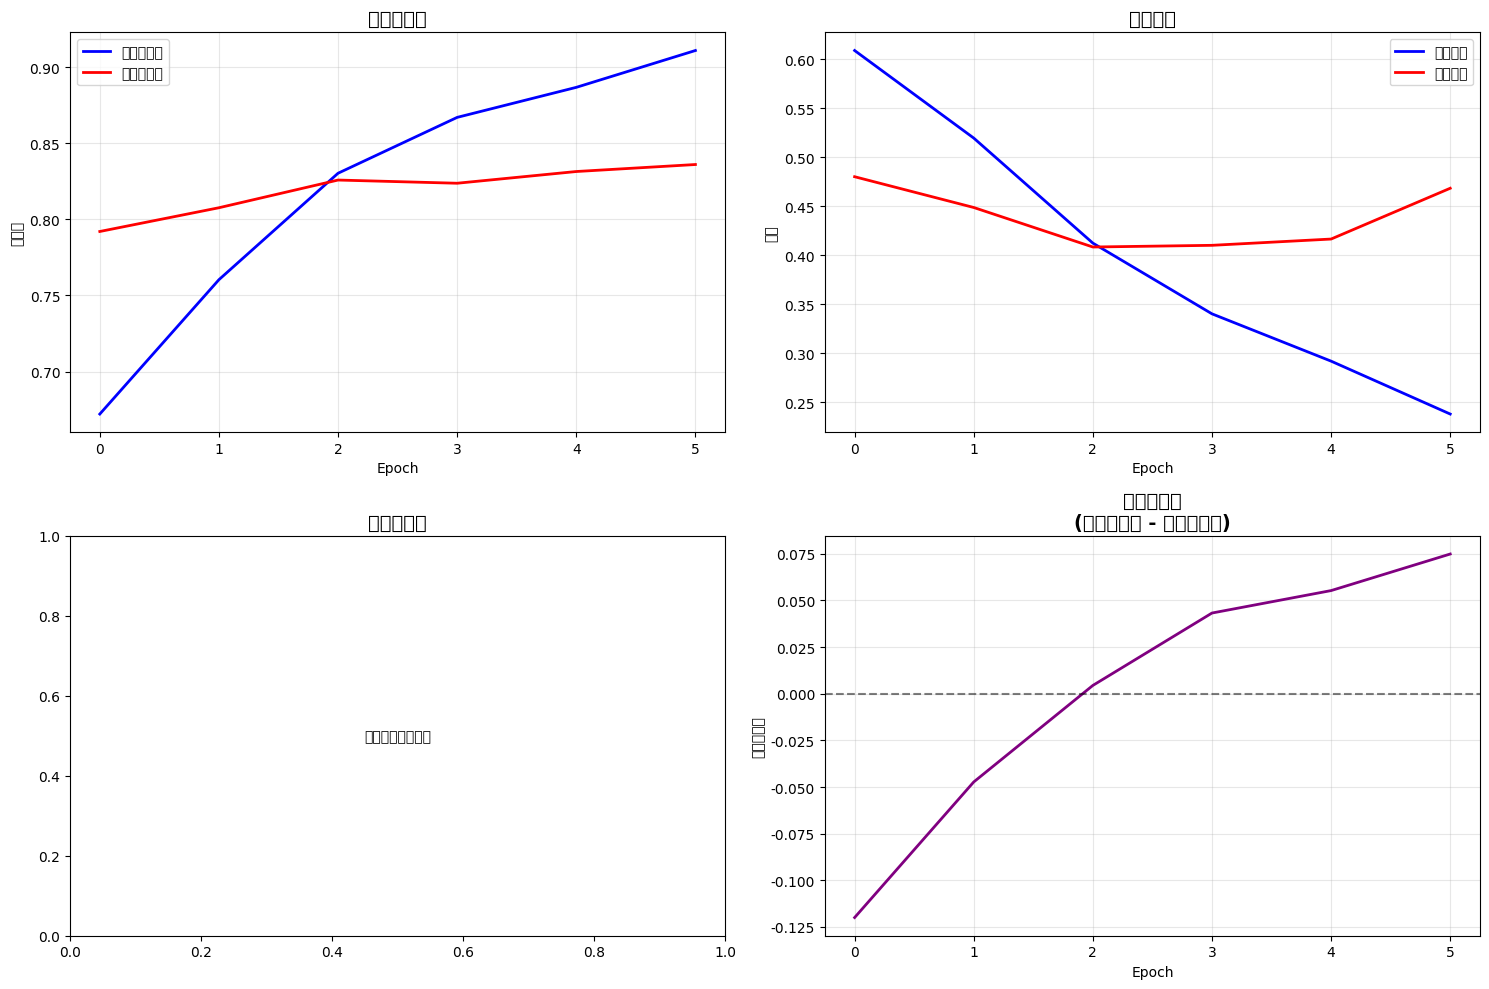


🔍 训练结果分析:
最终训练准确率: 0.9109
最终验证准确率: 0.8360
最佳验证准确率: 0.8360
训练-验证准确率差异: 0.0749
⚠️ 可能存在过拟合，考虑增加正则化
👍 模型性能良好


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 可视化训练历史
print("📈 可视化训练过程...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 准确率曲线
if "accuracy" in history.history and "val_accuracy" in history.history:
    axes[0, 0].plot(history.history['accuracy'], 'b-', label='训练准确率', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], 'r-', label='验证准确率', linewidth=2)
    axes[0, 0].set_title('模型准确率', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('准确率')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, '准确率数据不可用', ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 0].set_title('模型准确率', fontsize=14, fontweight='bold')

# 损失曲线
axes[0, 1].plot(history.history['loss'], 'b-', label='训练损失', linewidth=2)
if "val_loss" in history.history:
    axes[0, 1].plot(history.history['val_loss'], 'r-', label='验证损失', linewidth=2)
axes[0, 1].set_title('模型损失', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('损失')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 学习率曲线（如果有）
if 'lr' in history.history:
    axes[1, 0].plot(history.history['lr'], 'g-', linewidth=2)
    axes[1, 0].set_title('学习率变化', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('学习率')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, '学习率数据不可用', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('学习率变化', fontsize=14, fontweight='bold')

# 训练 vs 验证准确率差异
if "accuracy" in history.history and "val_accuracy" in history.history:
    train_val_diff = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])
    axes[1, 1].plot(train_val_diff, 'purple', linewidth=2)
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 1].set_title('过拟合分析\n(训练准确率 - 验证准确率)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('准确率差异')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, '准确率差异不可用', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('过拟合分析', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 分析训练结果
print("\n🔍 训练结果分析:")
if "accuracy" in history.history and "val_accuracy" in history.history:
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    best_val_acc = max(history.history['val_accuracy'])
    accuracy_gap = final_train_acc - final_val_acc

    print(f"最终训练准确率: {final_train_acc:.4f}")
    print(f"最终验证准确率: {final_val_acc:.4f}")
    print(f"最佳验证准确率: {best_val_acc:.4f}")
    print(f"训练-验证准确率差异: {accuracy_gap:.4f}")

    if accuracy_gap > 0.05:
        print("⚠️ 可能存在过拟合，考虑增加正则化")
    elif accuracy_gap < -0.02:
        print("📈 可能存在欠拟合，考虑增加模型复杂度")
    else:
        print("✅ 模型拟合良好")

    if best_val_acc > 0.85:
        print("🎉 模型性能优秀!")
    elif best_val_acc > 0.75:
        print("👍 模型性能良好")
    else:
        print("📝 模型性能有待提升")
else:
    print("ℹ️ 无准确率指标，可能使用了回归任务或未设置 metrics=['accuracy']")

## 6. 模型评估

全面评估训练好的模型性能，包括各种指标计算和可视化分析。

### 6.1 测试集评估

In [26]:
# 加载最佳模型（如果保存了的话）
if os.path.exists('best_lstm_model.h5'):
    print("📦 加载最佳保存的模型...")
    best_model = tf.keras.models.load_model('best_lstm_model.h5')
    print("✅ 模型加载成功!")
else:
    print("📝 使用当前训练的模型...")
    best_model = model

# 在测试集上进行预测
print("\n🔮 在测试集上进行预测...")
test_predictions = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_predictions_binary = (test_predictions > 0.5).astype(int).flatten()

# 计算测试集准确率
test_accuracy = accuracy_score(y_test, test_predictions_binary)
test_auc = roc_auc_score(y_test, test_predictions)

print(f"\n📊 测试集性能:")
print(f"准确率: {test_accuracy:.4f}")
print(f"AUC分数: {test_auc:.4f}")

# 详细分类报告
print(f"\n📋 详细分类报告:")
class_names = ['负面', '正面']
report = classification_report(y_test, test_predictions_binary,
                             target_names=class_names, digits=4)
print(report)

📦 加载最佳保存的模型...


✅ 模型加载成功!

🔮 在测试集上进行预测...
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step

📊 测试集性能:
准确率: 0.8356
AUC分数: 0.9110

📋 详细分类报告:
              precision    recall  f1-score   support

          负面     0.8284    0.8466    0.8374      5000
          正面     0.8431    0.8246    0.8338      5000

    accuracy                         0.8356     10000
   macro avg     0.8358    0.8356    0.8356     10000
weighted avg     0.8358    0.8356    0.8356     10000



### 6.2 混淆矩阵和ROC曲线

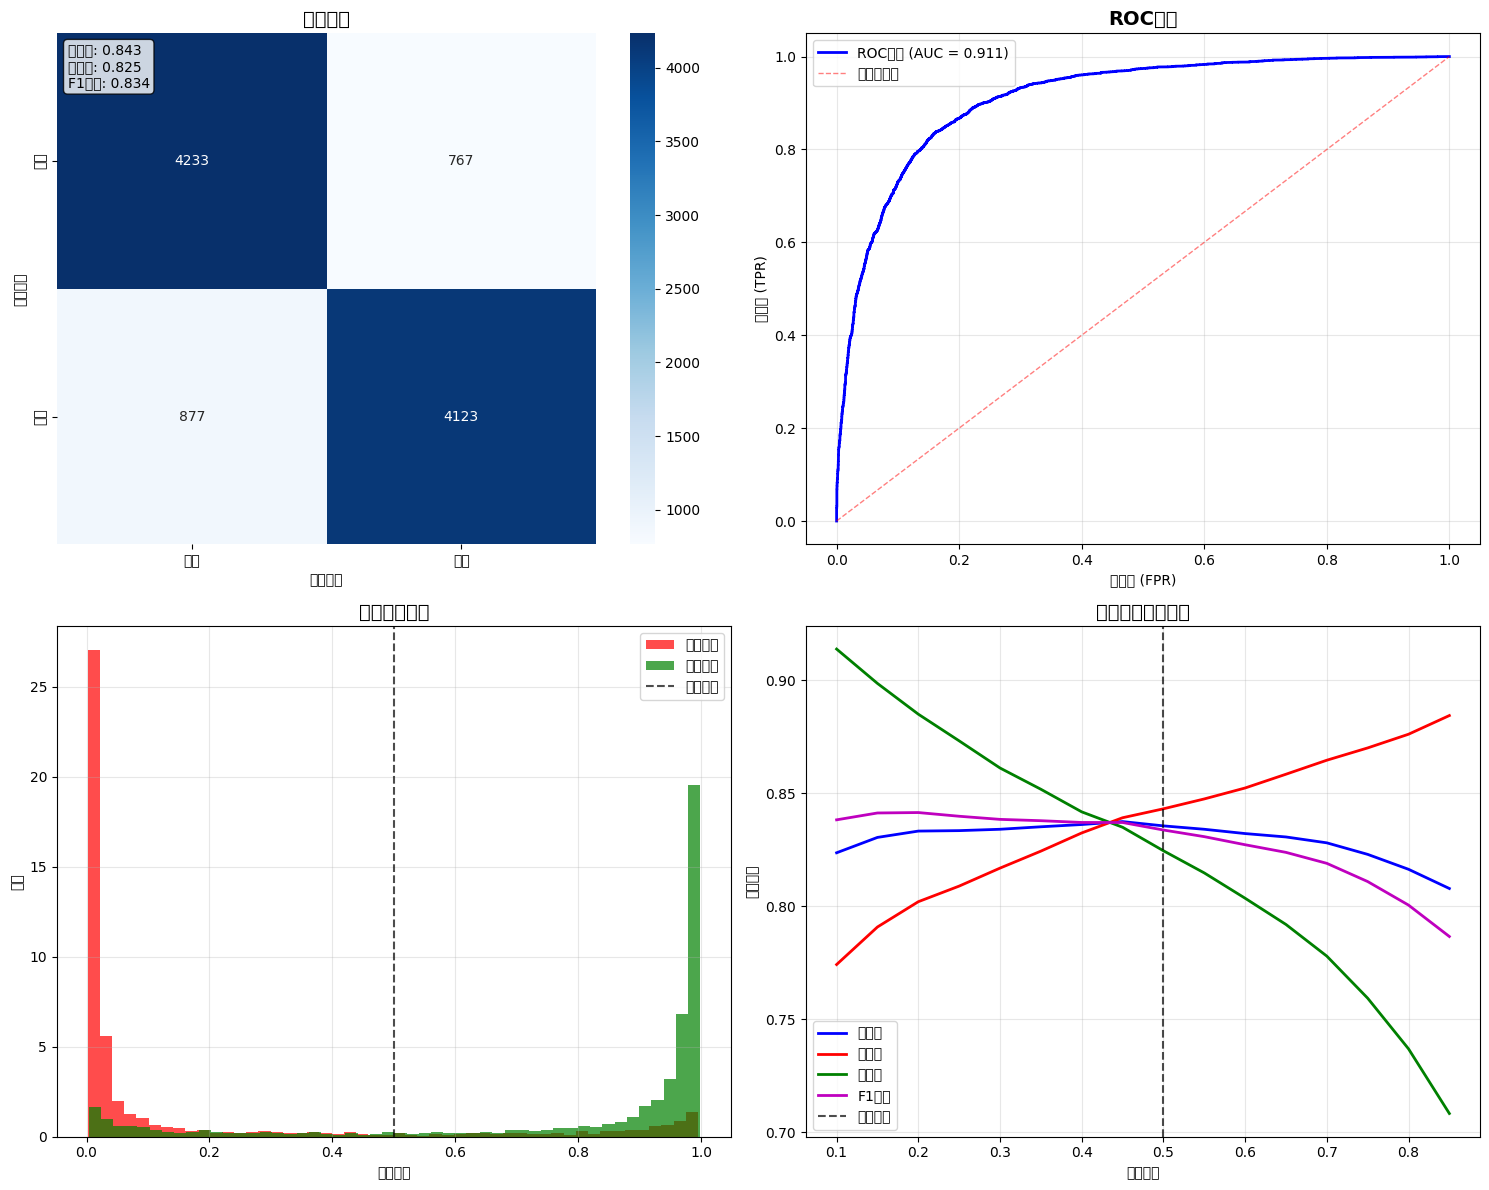


🎯 最佳分类阈值: 0.20 (F1分数: 0.8415)


In [28]:
# 可视化评估结果
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 混淆矩阵
cm = confusion_matrix(y_test, test_predictions_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
axes[0, 0].set_title('混淆矩阵', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('预测标签')
axes[0, 0].set_ylabel('真实标签')

# 添加混淆矩阵统计信息
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

stats_text = f'精确率: {precision:.3f}\n召回率: {recall:.3f}\nF1分数: {f1_score:.3f}'
axes[0, 0].text(0.02, 0.98, stats_text, transform=axes[0, 0].transAxes,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, test_predictions)
axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC曲线 (AUC = {test_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=1, alpha=0.5, label='随机分类器')
axes[0, 1].set_title('ROC曲线', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('假正率 (FPR)')
axes[0, 1].set_ylabel('真正率 (TPR)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 预测概率分布
axes[1, 0].hist(test_predictions[y_test == 0], bins=50, alpha=0.7,
               color='red', label='负面评论', density=True)
axes[1, 0].hist(test_predictions[y_test == 1], bins=50, alpha=0.7,
               color='green', label='正面评论', density=True)
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', alpha=0.7, label='决策边界')
axes[1, 0].set_title('预测概率分布', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('预测概率')
axes[1, 0].set_ylabel('密度')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 不同阈值下的性能
threshold_range = np.arange(0.1, 0.9, 0.05)
accuracies = []
precisions = []
recalls = []
f1_scores = []

from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in threshold_range:
    pred_binary = (test_predictions > threshold).astype(int).flatten()
    acc = accuracy_score(y_test, pred_binary)

    if len(np.unique(pred_binary)) > 1:  # 避免只有一个类别的情况
        prec = precision_score(y_test, pred_binary, zero_division=0)
        rec = recall_score(y_test, pred_binary, zero_division=0)
        f1 = f1_score(y_test, pred_binary, zero_division=0)
    else:
        prec = rec = f1 = 0

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

axes[1, 1].plot(threshold_range, accuracies, 'b-', label='准确率', linewidth=2)
axes[1, 1].plot(threshold_range, precisions, 'r-', label='精确率', linewidth=2)
axes[1, 1].plot(threshold_range, recalls, 'g-', label='召回率', linewidth=2)
axes[1, 1].plot(threshold_range, f1_scores, 'm-', label='F1分数', linewidth=2)
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.7, label='默认阈值')
axes[1, 1].set_title('不同阈值下的性能', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('分类阈值')
axes[1, 1].set_ylabel('性能指标')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 找到最佳阈值
best_threshold_idx = np.argmax(f1_scores)
best_threshold = threshold_range[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"\n🎯 最佳分类阈值: {best_threshold:.2f} (F1分数: {best_f1:.4f})")

### 6.3 错误分析

🔍 错误分析...
错误预测数量: 1644 / 10000 (16.4%)

假正例 (预测正面，实际负面): 767
假负例 (预测负面，实际正面): 877

📝 假正例样本 (最有信心的错误预测):

示例 1:
预测概率: 0.995
预测标签: 正面
实际标签: 负面
序列长度: 99
------------------------------

示例 2:
预测概率: 0.995
预测标签: 正面
实际标签: 负面
序列长度: 100
------------------------------

示例 3:
预测概率: 0.993
预测标签: 正面
实际标签: 负面
序列长度: 100
------------------------------

📝 假负例样本 (最有信心的错误预测):

示例 1:
预测概率: 0.003
预测标签: 负面
实际标签: 正面
序列长度: 100
------------------------------

示例 2:
预测概率: 0.003
预测标签: 负面
实际标签: 正面
序列长度: 100
------------------------------

示例 3:
预测概率: 0.004
预测标签: 负面
实际标签: 正面
序列长度: 100
------------------------------

📊 预测置信度分析:
高置信度正确预测: 72605284 (726052.8%)
高置信度错误预测: 14284716 (142847.2%)


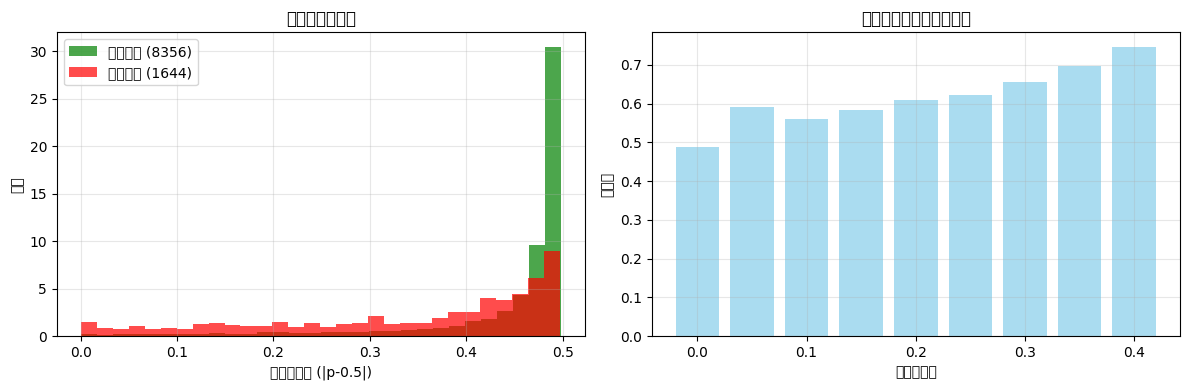

In [29]:
# 错误分析
print("🔍 错误分析...")

# 找出预测错误的样本
wrong_predictions = np.where(test_predictions_binary != y_test)[0]
print(f"错误预测数量: {len(wrong_predictions)} / {len(y_test)} ({len(wrong_predictions)/len(y_test)*100:.1f}%)")

# 分析误分类样本
false_positives = np.where((test_predictions_binary == 1) & (y_test == 0))[0]  # 假正例
false_negatives = np.where((test_predictions_binary == 0) & (y_test == 1))[0]  # 假负例

print(f"\n假正例 (预测正面，实际负面): {len(false_positives)}")
print(f"假负例 (预测负面，实际正面): {len(false_negatives)}")

# 显示一些误分类的例子
def show_misclassified_examples(indices, title, max_examples=3):
    print(f"\n{title}:")
    print("="*50)

    # 按预测置信度排序
    if len(indices) > 0:
        confidences = np.abs(test_predictions[indices] - 0.5).flatten()
        sorted_indices = indices[np.argsort(-confidences)][:max_examples]

        for i, idx in enumerate(sorted_indices):
            actual_text_idx = idx  # 这里需要映射回原始文本索引
            print(f"\n示例 {i+1}:")
            print(f"预测概率: {test_predictions[idx][0]:.3f}")
            print(f"预测标签: {'正面' if test_predictions_binary[idx] == 1 else '负面'}")
            print(f"实际标签: {'正面' if y_test[idx] == 1 else '负面'}")
            # 注意：这里无法直接显示原始文本，因为测试集索引可能与原始数据索引不对应
            print(f"序列长度: {np.sum(X_test[idx] != 0)}")
            print("-" * 30)

show_misclassified_examples(false_positives, "📝 假正例样本 (最有信心的错误预测)")
show_misclassified_examples(false_negatives, "📝 假负例样本 (最有信心的错误预测)")

# 预测置信度分析
print(f"\n📊 预测置信度分析:")
confident_correct = np.where((np.abs(test_predictions - 0.5) > 0.3) &
                           (test_predictions_binary == y_test))[0]
confident_wrong = np.where((np.abs(test_predictions - 0.5) > 0.3) &
                         (test_predictions_binary != y_test))[0]

print(f"高置信度正确预测: {len(confident_correct)} ({len(confident_correct)/len(y_test)*100:.1f}%)")
print(f"高置信度错误预测: {len(confident_wrong)} ({len(confident_wrong)/len(y_test)*100:.1f}%)")

# 可视化置信度分布
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
correct_confidences = np.abs(test_predictions[test_predictions_binary == y_test] - 0.5)
wrong_confidences = np.abs(test_predictions[test_predictions_binary != y_test] - 0.5)

plt.hist(correct_confidences, bins=30, alpha=0.7, color='green',
         label=f'正确预测 ({len(correct_confidences)})', density=True)
plt.hist(wrong_confidences, bins=30, alpha=0.7, color='red',
         label=f'错误预测 ({len(wrong_confidences)})', density=True)
plt.xlabel('预测置信度 (|p-0.5|)')
plt.ylabel('密度')
plt.title('预测置信度分布')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# 不同置信度区间的准确率
confidence_bins = np.arange(0, 0.5, 0.05)
accuracy_by_confidence = []
for i in range(len(confidence_bins)-1):
    mask = (np.abs(test_predictions - 0.5).flatten() >= confidence_bins[i]) & \
           (np.abs(test_predictions - 0.5).flatten() < confidence_bins[i+1])
    if np.sum(mask) > 0:
        acc = accuracy_score(y_test[mask], test_predictions_binary[mask])
    else:
        acc = 0
    accuracy_by_confidence.append(acc)

plt.bar(confidence_bins[:-1], accuracy_by_confidence, width=0.04, alpha=0.7, color='skyblue')
plt.xlabel('置信度区间')
plt.ylabel('准确率')
plt.title('不同置信度区间的准确率')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 模型预测和应用

实现一个完整的预测系统，可以对新的电影评论进行情感分析。

### 7.1 预测函数实现

In [30]:
def predict_sentiment(text, model, tokenizer, max_length, threshold=0.5):
    """
    预测单条文本的情感

    参数:
        text: 输入文本
        model: 训练好的模型
        tokenizer: 分词器
        max_length: 最大序列长度
        threshold: 分类阈值

    返回:
        dict: 包含预测结果的字典
    """

    # 文本清理
    cleaned_text = clean_text(text)

    # 文本转换为序列
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # 序列填充
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post')

    # 预测
    prediction = model.predict(padded_sequence, verbose=0)[0][0]

    # 结果解释
    predicted_class = 1 if prediction > threshold else 0
    sentiment_label = '正面' if predicted_class == 1 else '负面'
    confidence = prediction if predicted_class == 1 else 1 - prediction

    return {
        'original_text': text,
        'cleaned_text': cleaned_text,
        'prediction_score': prediction,
        'predicted_class': predicted_class,
        'sentiment_label': sentiment_label,
        'confidence': confidence,
        'sequence_length': len([x for x in padded_sequence[0] if x != 0])
    }

def batch_predict_sentiment(texts, model, tokenizer, max_length, threshold=0.5):
    """
    批量预测文本情感

    参数:
        texts: 文本列表
        model: 训练好的模型
        tokenizer: 分词器
        max_length: 最大序列长度
        threshold: 分类阈值

    返回:
        list: 预测结果列表
    """

    results = []

    # 批量处理
    cleaned_texts = [clean_text(text) for text in texts]
    sequences = tokenizer.texts_to_sequences(cleaned_texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

    # 批量预测
    predictions = model.predict(padded_sequences, verbose=0)

    # 处理结果
    for i, (text, prediction) in enumerate(zip(texts, predictions)):
        predicted_class = 1 if prediction[0] > threshold else 0
        sentiment_label = '正面' if predicted_class == 1 else '负面'
        confidence = prediction[0] if predicted_class == 1 else 1 - prediction[0]

        results.append({
            'original_text': text,
            'cleaned_text': cleaned_texts[i],
            'prediction_score': prediction[0],
            'predicted_class': predicted_class,
            'sentiment_label': sentiment_label,
            'confidence': confidence,
            'sequence_length': len([x for x in padded_sequences[i] if x != 0])
        })

    return results

print("✅ 预测函数定义完成!")

✅ 预测函数定义完成!


### 7.2 单条评论预测示例

In [31]:
# 测试单条预测
print("🔮 单条评论情感预测测试:")
print("="*50)

# 准备一些测试评论
test_reviews = [
    "This movie is absolutely fantastic! I loved every minute of it.",
    "Terrible movie, waste of time. Very disappointed.",
    "The movie was okay, nothing special but not bad either.",
    "Amazing cinematography and brilliant acting. Highly recommended!",
    "I fell asleep halfway through. Boring and predictable.",
    "一部非常精彩的电影，强烈推荐！",  # 中文测试
    "The plot was confusing and the characters were poorly developed.",
    "Outstanding performance by all actors. A masterpiece!",
    "Not the worst movie I've seen, but definitely not the best.",
    "Exceptional storytelling and beautiful visuals. Perfect!"
]

# 对每条评论进行预测
for i, review in enumerate(test_reviews):
    print(f"\n📝 评论 {i+1}:")
    print(f"原文: {review}")

    result = predict_sentiment(review, best_model, tokenizer, MAX_LENGTH)

    print(f"情感预测: {result['sentiment_label']} (置信度: {result['confidence']:.3f})")
    print(f"预测分数: {result['prediction_score']:.3f}")
    print(f"序列长度: {result['sequence_length']}")
    print("-" * 30)

# 统计预测结果
all_results = [predict_sentiment(review, best_model, tokenizer, MAX_LENGTH)
               for review in test_reviews]

positive_count = sum(1 for r in all_results if r['predicted_class'] == 1)
negative_count = sum(1 for r in all_results if r['predicted_class'] == 0)
avg_confidence = np.mean([r['confidence'] for r in all_results])

print(f"\n📊 预测统计:")
print(f"正面评论: {positive_count} / {len(test_reviews)}")
print(f"负面评论: {negative_count} / {len(test_reviews)}")
print(f"平均置信度: {avg_confidence:.3f}")

🔮 单条评论情感预测测试:

📝 评论 1:
原文: This movie is absolutely fantastic! I loved every minute of it.
情感预测: 正面 (置信度: 0.991)
预测分数: 0.991
序列长度: 11
------------------------------

📝 评论 2:
原文: Terrible movie, waste of time. Very disappointed.
情感预测: 负面 (置信度: 0.989)
预测分数: 0.011
序列长度: 7
------------------------------

📝 评论 3:
原文: The movie was okay, nothing special but not bad either.
情感预测: 负面 (置信度: 0.977)
预测分数: 0.023
序列长度: 10
------------------------------

📝 评论 4:
原文: Amazing cinematography and brilliant acting. Highly recommended!
情感预测: 正面 (置信度: 0.992)
预测分数: 0.992
序列长度: 7
------------------------------

📝 评论 5:
原文: I fell asleep halfway through. Boring and predictable.
情感预测: 负面 (置信度: 0.987)
预测分数: 0.013
序列长度: 8
------------------------------

📝 评论 6:
原文: 一部非常精彩的电影，强烈推荐！
情感预测: 正面 (置信度: 0.712)
预测分数: 0.712
序列长度: 0
------------------------------

📝 评论 7:
原文: The plot was confusing and the characters were poorly developed.
情感预测: 负面 (置信度: 0.983)
预测分数: 0.017
序列长度: 10
------------------------------

📝 评论 8:
原

### 7.3 批量预测和实际应用

In [32]:
import numpy as np
import pickle

# 批量预测示例
print("🔄 批量预测测试:")
print("=" * 50)

# 从原始数据中随机选择一些样本进行预测
np.random.seed(42)
random_indices = np.random.choice(len(df), 10, replace=False)
sample_reviews = df.iloc[random_indices]['review'].tolist()
sample_labels = df.iloc[random_indices]['sentiment'].tolist()

# 批量预测
batch_results = batch_predict_sentiment(sample_reviews, best_model, tokenizer, MAX_LENGTH)

# 显示结果
print(f"\n📊 批量预测结果:")
correct_predictions = 0

for i, (result, actual_label) in enumerate(zip(batch_results, sample_labels)):
    actual_class = 1 if actual_label == 'positive' else 0
    is_correct = result['predicted_class'] == actual_class
    if is_correct:
        correct_predictions += 1

    print(f"\n样本 {i+1}:")
    print(f"原文: {result['original_text'][:100]}...")
    print(f"实际标签: {actual_label}")
    print(f"预测标签: {result['sentiment_label']} (置信度: {result['confidence']:.3f})")
    print(f"预测正确: {'✅' if is_correct else '❌'}")
    print("-" * 40)

accuracy = correct_predictions / len(batch_results)
print(f"\n🎯 批量预测准确率: {accuracy:.3f} ({correct_predictions}/{len(batch_results)})")

# 模型保存
print(f"\n💾 保存模型和相关文件...")

# 保存模型
model_save_path = 'lstm_sentiment_model.h5'
best_model.save(model_save_path)
print(f"✅ 模型已保存到: {model_save_path}")

# 保存分词器
tokenizer_save_path = 'tokenizer.pkl'
with open(tokenizer_save_path, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"✅ 分词器已保存到: {tokenizer_save_path}")

# 保存模型配置
config = {
    'MAX_WORDS': MAX_WORDS,
    'MAX_LENGTH': MAX_LENGTH,
    'EMBEDDING_DIM': EMBEDDING_DIM,
    'LSTM_UNITS': LSTM_UNITS,
    'DENSE_UNITS': DENSE_UNITS,
    'DROPOUT_RATE': DROPOUT_RATE,
    'vocab_size': min(MAX_WORDS, len(word_index)) + 1,
    'best_threshold': best_threshold,
    'test_accuracy': test_accuracy,
    'test_auc': test_auc
}

config_save_path = 'model_config.pkl'
with open(config_save_path, 'wb') as f:
    pickle.dump(config, f)
print(f"✅ 模型配置已保存到: {config_save_path}")

print(f"\n🎉 模型部署文件准备完成！")
print("要使用模型进行预测，需要加载以下文件：")
print(f"1. 模型文件: {model_save_path}")
print(f"2. 分词器: {tokenizer_save_path}")
print(f"3. 配置文件: {config_save_path}")

🔄 批量预测测试:



📊 批量预测结果:

样本 1:
原文: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall ...
实际标签: positive
预测标签: 负面 (置信度: 0.811)
预测正确: ❌
----------------------------------------

样本 2:
原文: Not many television shows appeal to quite as many different kinds of fans like Farscape does...I kno...
实际标签: positive
预测标签: 正面 (置信度: 0.994)
预测正确: ✅
----------------------------------------

样本 3:
原文: The film quickly gets to a major chase scene with ever increasing destruction. The first really bad ...
实际标签: negative
预测标签: 负面 (置信度: 0.993)
预测正确: ✅
----------------------------------------

样本 4:
原文: Jane Austen would definitely approve of this one!<br /><br />Gwyneth Paltrow does an awesome job cap...
实际标签: positive
预测标签: 正面 (置信度: 0.998)
预测正确: ✅
----------------------------------------

样本 5:
原文: Expectations were somewhat high for me when I went to see this movie, after all I thought Steve Care...
实际标签: negative
预测标签: 负面 (置信度: 0.989)
预测正确: ✅
-------------------------

## 8. 模型优化建议

### 8.1 超参数调优建议

**🔧 模型架构参数：**

1. **词汇表大小 (MAX_WORDS)**
   - 当前值: 10,000
   - 建议: 尝试 15,000-20,000，平衡性能与计算复杂度
   - 影响: 更大的词汇表可能提高表达能力，但增加计算开销

2. **序列最大长度 (MAX_LENGTH)**
   - 当前值: 100
   - 建议: 根据数据分析结果，尝试 150-200
   - 影响: 更长序列保留更多信息，但增加计算时间

3. **词嵌入维度 (EMBEDDING_DIM)**
   - 当前值: 128
   - 建议: 尝试 200-300 维度
   - 影响: 更高维度可能捕获更丰富的语义信息

4. **LSTM单元数 (LSTM_UNITS)**
   - 当前值: 64
   - 建议: 尝试 128-256
   - 影响: 更多单元增加模型容量，可能提高性能

**⚙️ 训练参数：**

1. **批次大小 (BATCH_SIZE)**
   - 当前值: 32
   - 建议: GPU充足时尝试 64-128
   - 影响: 更大批次提供更稳定的梯度估计

2. **学习率**
   - 当前: Adam默认 (0.001)
   - 建议: 尝试 0.0005-0.002，使用学习率调度
   - 影响: 适当的学习率加快收敛

3. **Dropout率**
   - 当前值: 0.3
   - 建议: 根据过拟合情况调整到 0.2-0.5
   - 影响: 平衡过拟合防护与模型表达能力

### 8.2 模型架构改进

**🏗️ 高级架构选项：**

1. **双向LSTM (Bidirectional LSTM)**
```python
   # 替换单向LSTM层
   Bidirectional(LSTM(units=lstm_units, return_sequences=False))
```
	•	优势: 同时利用前向和后向信息
	•	缺点: 参数量翻倍，计算时间增加

	2.	多层LSTM
```
# 堆叠多个LSTM层
LSTM(units=lstm_units, return_sequences=True),
Dropout(dropout_rate),
LSTM(units=lstm_units//2, return_sequences=False)
```
	•	优势: 增加模型深度和表达能力
	•	注意: 需要合理设置return_sequences

	3.	注意力机制 (Attention)
```
from tensorflow.keras.layers import Attention
# 在LSTM后添加注意力层
```
	•	优势: 动态关注重要信息
	•	适用: 长序列文本分析

	4.	卷积神经网络 + LSTM
```
Conv1D(filters=32, kernel_size=3, activation='relu'),
GlobalMaxPooling1D(),
# 然后连接到LSTM
```
	•	优势: 提取局部特征模式
	•	适用: 捕获短语级别的情感表达

🔄 集成学习方法：

	1.	模型集成
	•	训练多个不同配置的模型
	•	使用投票或加权平均进行预测
	•	显著提升预测稳定性
	2.	交叉验证
	•	使用K折交叉验证评估模型
	•	获得更可靠的性能估计

### 8.3 数据增强和预处理改进

**📝 文本数据增强：**

1. **同义词替换**
   ```python
   import nltk
   from nltk.corpus import wordnet
   # 随机替换部分词汇为同义词

	2.	回译 (Back Translation)

# 英语 -> 其他语言 -> 英语
# 增加数据多样性


	3.	随机插入和删除
	•	随机插入停用词
	•	随机删除部分词汇
	•	保持语义不变

🔧 预处理优化：
	1.	预训练词向量
```
# 使用GloVe或Word2Vec预训练向量
embedding_matrix = create_embedding_matrix(word_index, embedding_dim)
Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False)
```

	2.	子词分词 (Subword Tokenization)

# 使用BPE或SentencePiece
# 处理未知词汇问题


	3.	文本清理改进
	•	保留重要的标点符号
	•	处理表情符号
	•	标准化缩写形式

⚖️ 数据平衡处理：
	1.	重采样技术
	•	过采样少数类
	•	欠采样多数类
	•	SMOTE技术
	2.	类权重调整

```
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
```
